# Прогнозирование итогового GPA студентов


## 1. Цель проекта

Целью проекта является построение модели машинного обучения для прогнозирования итогового среднего балла (Final_CGPA) студентов на основе их академических и поведенческих характеристик.

В рамках проекта выполнены:
- разведочный анализ данных (EDA),
- подготовка признаков,
- обучение моделей Random Forest и XGBoost,
- сравнение качества моделей.


In [ ]:
# Работа с данными
import pandas as pd
import numpy as np

# Визуализация
import matplotlib.pyplot as plt
import seaborn as sns

# Разделение данных
from sklearn.model_selection import train_test_split

# Модели
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Метрики
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Сохранение модели
import joblib

In [ ]:
import sys
print(sys.executable)

/mnt/data/ml-students-gpa/venv/bin/python


In [4]:
df = pd.read_csv("../data/students.csv")

df.head()

,Student_ID,Gender,Age,Major,Attendance_Pct,Study_Hours_Per_Day,Previous_GPA,Sleep_Hours,Social_Hours_Week,Final_CGPA
0,ID00001,Male,20,Engineering,83.9,4.4,2.65,9.1,8,2.78
1,ID00002,Female,24,Business,80.7,4.0,3.58,4.0,4,3.76
2,ID00003,Female,20,Mathematics,91.5,3.9,3.29,6.7,4,3.75
3,ID00004,Female,23,Engineering,73.9,8.8,3.48,4.0,6,3.69
4,ID00005,Male,21,Economics,79.8,2.2,2.66,8.7,6,2.34


In [6]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Gender               5000 non-null   str    
 1   Age                  5000 non-null   int64  
 2   Major                5000 non-null   str    
 3   Attendance_Pct       5000 non-null   float64
 4   Study_Hours_Per_Day  5000 non-null   float64
 5   Previous_GPA         5000 non-null   float64
 6   Sleep_Hours          5000 non-null   float64
 7   Social_Hours_Week    5000 non-null   int64  
 8   Final_CGPA           5000 non-null   float64
dtypes: float64(5), int64(2), str(2)
memory usage: 351.7 KB


Gender                 0
Age                    0
Major                  0
Attendance_Pct         0
Study_Hours_Per_Day    0
Previous_GPA           0
Sleep_Hours            0
Social_Hours_Week      0
Final_CGPA             0
dtype: int64

## Удаление столбца student_id 

In [5]:
df = df.drop("Student_ID", axis=1)

## Распределение Final_CGPA

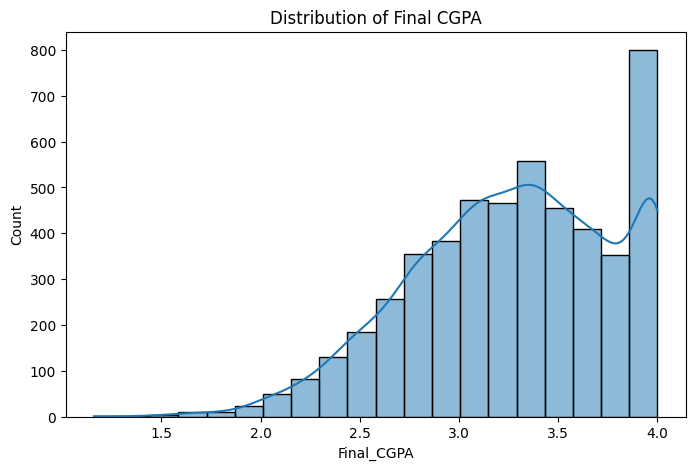

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df["Final_CGPA"], bins=20, kde=True)
plt.title("Distribution of Final CGPA")
plt.show()

## Корреляционная матрица

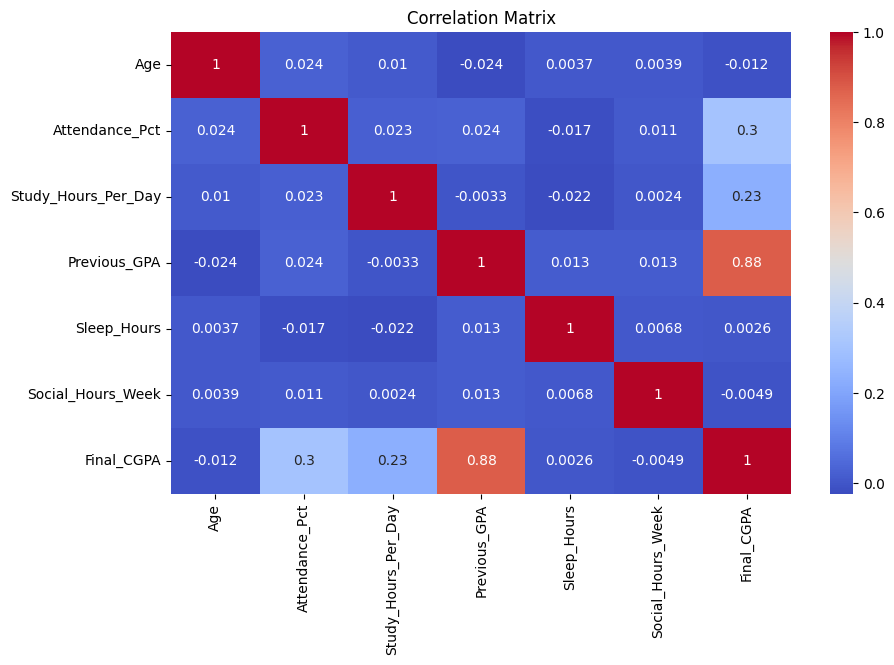

In [8]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

## Зависимости
### GPA vs Study Hours

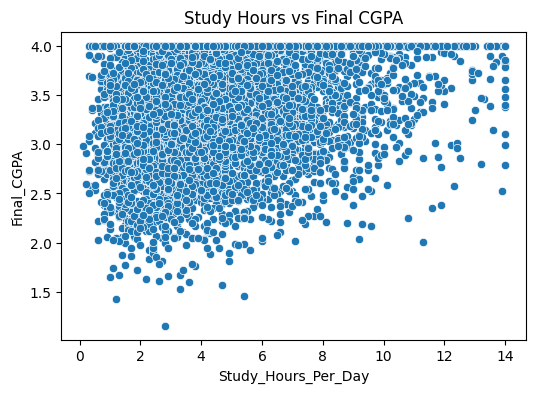

In [9]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["Study_Hours_Per_Day"], y=df["Final_CGPA"])
plt.title("Study Hours vs Final CGPA")
plt.show()

### GPA vs Attendance

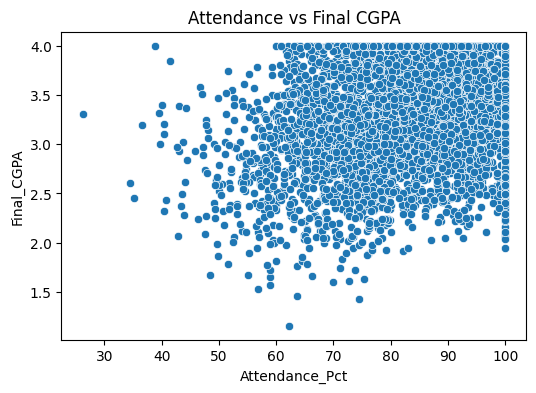

In [10]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["Attendance_Pct"], y=df["Final_CGPA"])
plt.title("Attendance vs Final CGPA")
plt.show()

## Кодирование категориальных признаков

In [11]:
df = pd.get_dummies(df, drop_first=True)
df.head()

,Age,Attendance_Pct,Study_Hours_Per_Day,Previous_GPA,Sleep_Hours,Social_Hours_Week,Final_CGPA,Gender_Male,Major_Computer Science,Major_Economics,Major_Engineering,Major_Mathematics,Major_Psychology
0,20,83.9,4.4,2.65,9.1,8,2.78,True,False,False,True,False,False
1,24,80.7,4.0,3.58,4.0,4,3.76,False,False,False,False,False,False
2,20,91.5,3.9,3.29,6.7,4,3.75,False,False,False,False,True,False
3,23,73.9,8.8,3.48,4.0,6,3.69,False,False,False,True,False,False
4,21,79.8,2.2,2.66,8.7,6,2.34,True,False,True,False,False,False


## Разделяем X и y

In [12]:
X = df.drop("Final_CGPA", axis=1)
y = df["Final_CGPA"]

## Train/Test split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Random forest

In [14]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)

## Оценка random forest

In [15]:
mae = mean_absolute_error(y_test, rf_preds)
rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
r2 = r2_score(y_test, rf_preds)

print("Random Forest Results:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

Random Forest Results:
MAE: 0.10222474999999995
RMSE: 0.1265106157502207
R2: 0.9441884196348578


## XGBoost

In [16]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_preds = xgb.predict(X_test)

## Оценка XGBoost

In [17]:
mae_xgb = mean_absolute_error(y_test, xgb_preds)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_preds))
r2_xgb = r2_score(y_test, xgb_preds)

print("XGBoost Results:")
print("MAE:", mae_xgb)
print("RMSE:", rmse_xgb)
print("R2:", r2_xgb)

XGBoost Results:
MAE: 0.09728720040321351
RMSE: 0.11688503599033337
R2: 0.9523581945875431


## Сравнение моделей

In [18]:
results = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "MAE": [mae, mae_xgb],
    "RMSE": [rmse, rmse_xgb],
    "R2": [r2, r2_xgb]
})

results

,Model,MAE,RMSE,R2
0,Random Forest,0.102225,0.126511,0.944188
1,XGBoost,0.097287,0.116885,0.952358


## Важность признаков (Feature Importance)

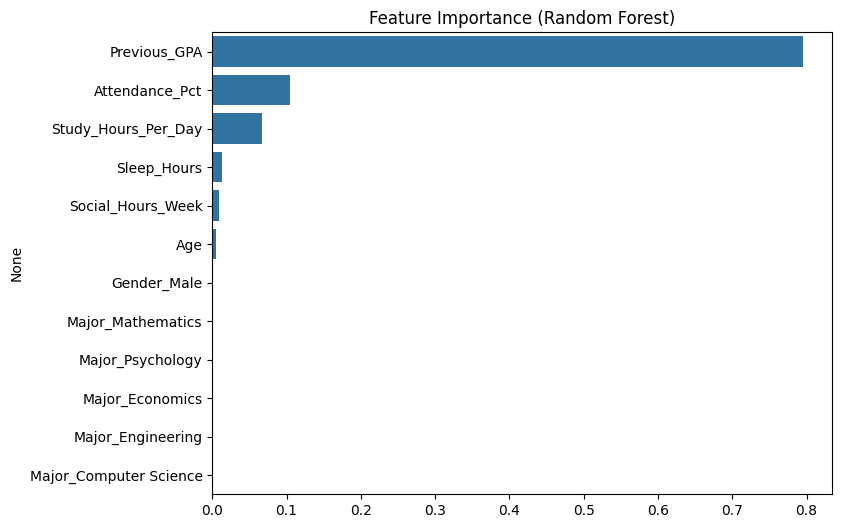

In [19]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Feature Importance (Random Forest)")
plt.show()

## SHAP

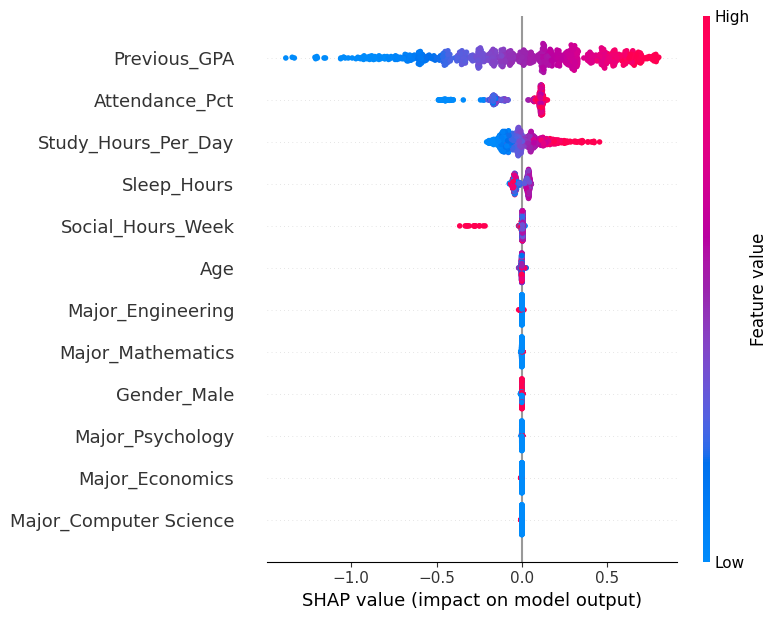

In [20]:
import shap

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

## сохранение лучшей модели

In [21]:
joblib.dump(xgb, "../models/xgboost_model.pkl")

['../models/xgboost_model.pkl']

In [24]:
xgb_preds = xgb.predict(X_test)
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": xgb_preds
})

results.head()

,Actual,Predicted
1501,3.11,3.090166
2586,3.70,3.735602
2653,2.93,2.813054
1055,2.67,2.485465
705,3.69,3.483739


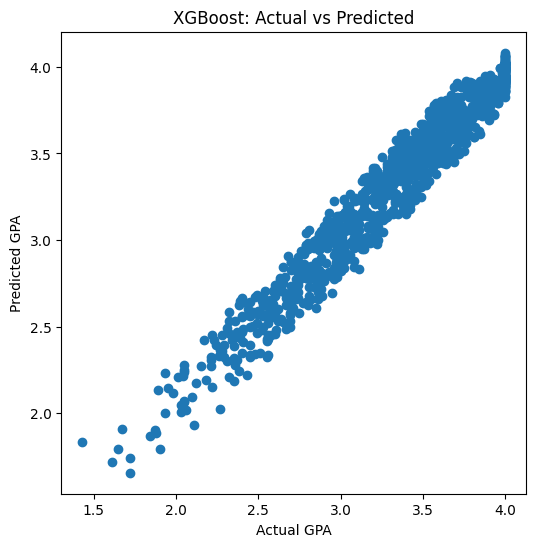

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, xgb_preds)
plt.xlabel("Actual GPA")
plt.ylabel("Predicted GPA")
plt.title("XGBoost: Actual vs Predicted")
plt.show()


## 2. Результаты моделей

### Random Forest
- MAE: 0.1022  
- RMSE: 0.1265  
- R²: 0.9442  

### XGBoost
- MAE: 0.0973  
- RMSE: 0.1169  
- R²: 0.9524  



## 3. Интерпретация метрик

- MAE показывает среднюю абсолютную ошибку прогноза. В нашем случае модель ошибается примерно на 0.1 балла GPA.
- RMSE отражает среднеквадратичную ошибку и сильнее штрафует крупные отклонения.
- R² показывает долю объяснённой дисперсии. Значение выше 0.95 у XGBoost говорит о высоком качестве модели.

Обе модели демонстрируют очень хорошую предсказательную способность.



## 4. Итоговые выводы

1. Ансамблевые методы на основе деревьев решений эффективно работают с табличными данными.
2. XGBoost показал наилучшее качество по всем метрикам.
3. Модель способна объяснить более 95% вариации итогового GPA.
4. Средняя ошибка предсказания составляет около 0.1 балла.

Таким образом, для финального использования рекомендуется модель XGBoost.
